# Avaliação de Modelos

Quais melhores modelos para testar as metricas
- Metricas a serem validadas:
    - F1 Score
    - ROC-AUC
- Modelos a serem testados:
    - Regressão
    - Decision Tree
    - randomforest
    - XGBoost

In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score,recall_score, precision_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay, PrecisionRecallDisplay
from src.data.load_data import import_dataset
from src.config import FEATURES,  TARGET
from src.preprocess import churn_mapped, create_preprocessor, train_test, total_charges
from src.train import train_model
from src.threshold import threshold, threshold_analysis


In [13]:
df = import_dataset(r"..\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df["TotalCharges"] = total_charges(df)

X = df[FEATURES]
y = churn_mapped(df, TARGET)

X_train, X_test, y_train, y_test = train_test(X,y)

models = train_model(X_train, y_train)

Modelo Logistic Regresison treinado
Modelo Decision Tree treinado
Modelo Random Forest treinado
Modelo XGBoost treinado


# Regressão Logistica

In [11]:
lr_model = models["Logistic Regresison"]
lr_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
y_pred = lr_model.predict(X_test)
y_proba = lr_model.predict_proba(X_test)[:,1]

print('Accuracy: ',accuracy_score(y_test, y_pred))
print('Recall: ', recall_score(y_test, y_pred))
print('Precision: ',precision_score(y_test, y_pred))
print('F1-Score: ', f1_score(y_test, y_pred))
print('ROC-AUC: ', roc_auc_score(y_test, y_proba))

Accuracy:  0.7374024130589071
Recall:  0.7834224598930482
Precision:  0.5034364261168385
F1-Score:  0.6129707112970711
ROC-AUC:  0.8414063912785139


# Arvore de Decisão

In [14]:
dt_model = models["Decision Tree"]
dt_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [15]:
y_pred = dt_model.predict(X_test)
y_proba = dt_model.predict_proba(X_test)[:,1]


print('Accuracy: ',accuracy_score(y_test, y_pred))
print('Recall: ', recall_score(y_test, y_pred))
print('Precision: ',precision_score(y_test, y_pred))
print('F1-Score: ', f1_score(y_test, y_pred))
print('ROC-AUC: ', roc_auc_score(y_test, y_proba))

Accuracy:  0.7544357700496807
Recall:  0.7566844919786097
Precision:  0.5260223048327137
F1-Score:  0.6206140350877193
ROC-AUC:  0.8317988064791133


# Random Forest

In [16]:
rf_model = models["Random Forest"]
rf_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [17]:
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:,1]

print('Accuracy: ',accuracy_score(y_test, y_pred))
print('Recall: ', recall_score(y_test, y_pred))
print('Precision: ',precision_score(y_test, y_pred))
print('F1-Score: ', f1_score(y_test, y_pred))
print('ROC-AUC: ', roc_auc_score(y_test, y_proba))

Accuracy:  0.7444996451383961
Recall:  0.7834224598930482
Precision:  0.5122377622377622
F1-Score:  0.6194503171247357
ROC-AUC:  0.8395631506884704


# XGBoost

In [18]:
ratio = (y_train ==0).sum()/(y_train==1).sum()
ratio

xgb_model = models["XGBoost"]
xgb_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:,1]

print('Accuracy: ', accuracy_score(y_test, y_pred))
print('Recall: ', recall_score(y_test, y_pred))
print('Precision: ', precision_score(y_test, y_pred))
print('F1-Score: ', f1_score(y_test, y_pred))
print('ROC-AUC: ', roc_auc_score(y_test, y_proba))

Accuracy:  0.7494677075940384
Recall:  0.7700534759358288
Precision:  0.518918918918919
F1-Score:  0.620021528525296
ROC-AUC:  0.8359967966106074


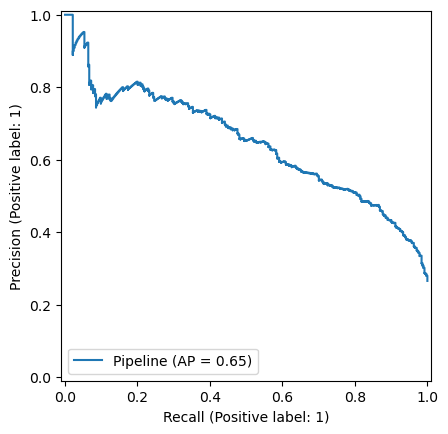

In [22]:
PrecisionRecallDisplay.from_estimator(xgb_model, X_test, y_test)
plt.show()

In [24]:
from sklearn.metrics import average_precision_score

y_proba = xgb_model.predict_proba(X_test)[:, 1]

ap=average_precision_score(y_test, y_proba)
print(ap)

0.6479384606844372


# Comparativo entre modelos

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
pipelines = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}
resultados = []

for nome, pipeline in pipelines.items():

    cv_score = cross_val_score(pipeline, X, y, cv=cv, scoring = 'roc_auc')    
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:,1]
    
    resultados.append({
        "Modelo": nome,
        "ROC_AUC Cross Validation": round(cv_score.mean(),4),
        "ROC_AUC std":              round(cv_score.std(),4),
        "ROC_AUC Test":             round(roc_auc_score(y_test, y_proba),4),
        "Recall":                   round(recall_score(y_test, y_pred),4),
        "Precision":                round(precision_score(y_test, y_pred),4),
        "F1 Score":                 round(f1_score(y_test, y_pred),4)        
    })
df_resultados = pd.DataFrame(resultados).sort_values("ROC_AUC Cross Validation", ascending= False)
df_resultados

,Modelo,ROC_AUC Cross Validation,ROC_AUC std,ROC_AUC Test,Recall,Precision,F1 Score
0,Logistic Regression,0.8449,0.0134,0.8414,0.7834,0.5034,0.6130
2,Random Forest,0.8430,0.0118,0.8396,0.7834,0.5122,0.6195
3,XGBoost,0.8373,0.0101,0.8360,0.7701,0.5189,0.6200
1,Decision Tree,0.8300,0.0105,0.8318,0.7567,0.5260,0.6206


## Resultado do comparativo

Observando a tabela acima, vemos que a metrica ROC-AUC, após a validação por cross validation, os resultados das médias são bem semelhantes ao teste e semelhantes entre si, tendo um desvio padrão baixo, o que resulta em boa estabilidade dos modelos (não "overfittam"). Assim, pela simplicidade, recall competitivo entre os modelos, maior ROC-AUC e precision semelhantes, a escolha do modelo de Logistic Regression aparenta ser a mais adequada.

A interpretação da regressão logisti se dá basicamente pelo peso que cada feature influencia no target, ou seja, se uma feature possui valores positivos altos, a probabiliade de contribuir para o Churn é maior e vice versa.

# Testes com alteração no Threshold

In [34]:
lf_th = threshold(lr_model,X_test,y_test)
lf_th

,threshold,precision,recall,f1
0,0.1,0.341,0.989,0.507
1,0.2,0.389,0.963,0.554
2,0.3,0.429,0.928,0.587
3,0.4,0.466,0.866,0.606
4,0.5,0.503,0.783,0.613
5,0.6,0.539,0.706,0.611
6,0.7,0.602,0.602,0.602
7,0.8,0.710,0.398,0.510


In [35]:
qtd_churn_real_test = sum(y_test)
churn_ident_model = sum(y_pred)
print(churn_ident_model)
print(qtd_churn_real_test)

696
374


In [36]:
y_proba = lr_model.predict_proba(X_test)[:, 1]
y_pred = y_proba >= 0.4
print("Precision: ",precision_score(y_test, y_pred))
print("Recall: ",recall_score(y_test, y_pred))
print("F1: ",f1_score(y_test, y_pred))

churn_ident_threshold = sum(y_pred)
print("Qtd Churn na amostra teste: ",qtd_churn_real_test)
print("Threshold 0.4: ", churn_ident_threshold)

Precision:  0.46551724137931033
Recall:  0.8663101604278075
F1:  0.6056074766355141
Qtd Churn na amostra teste:  374
Threshold 0.4:  696


In [37]:
df_threshold = threshold_analysis(
    lr_model,
    X_test,
    y_test,
    ltv_medio= df["MonthlyCharges"].mean(),
    taxa_conversao= 0.3,
    custo_contrato= 10
)
df_threshold

,Threshold,Precision,Recall,F1,Capturados,Abordados,Receita Mensal,Receita Anual,Custo,ROI
0,0.1,0.341014,0.989305,0.507197,370,1085.0,7189.0,86263.0,10850.0,-33.7
1,0.2,0.388769,0.962567,0.553846,360,926.0,6994.0,83931.0,9260.0,-24.5
2,0.3,0.429455,0.927807,0.587140,347,808.0,6742.0,80900.0,8080.0,-16.6
3,0.4,0.465517,0.866310,0.605607,324,696.0,6295.0,75538.0,6960.0,-9.6
4,0.5,0.503436,0.783422,0.612971,293,582.0,5693.0,68311.0,5820.0,-2.2
5,0.6,0.538776,0.705882,0.611111,264,490.0,5129.0,61550.0,4900.0,4.7
6,0.7,0.601604,0.601604,0.601604,225,374.0,4371.0,52457.0,3740.0,16.9
7,0.8,0.709524,0.398396,0.510274,149,210.0,2895.0,34738.0,2100.0,37.8


Com os testes de Threshold, vemos que se a campanha for de captação de receita de apenas um mês, o precision precisa ter uma relevancia maior,sendo o threshold de 0.6 a melhor opção, pois é preciso acertar mais para identificar os clientes que deram Churn real. Porém, se a campanha tem o intuito de fidelizar o cliente, então o valor mensal que teremos de receita ultrapassará muito o custo da campanha, então o threshold de 0.4 é mais eficaz, pois possui um retorno a longo prazo muito maior, pois a retenção de da quantidade de Churn é significativamente maior do que os abordados de forma "errada", no periodo de 12 meses.

# ROC Curve

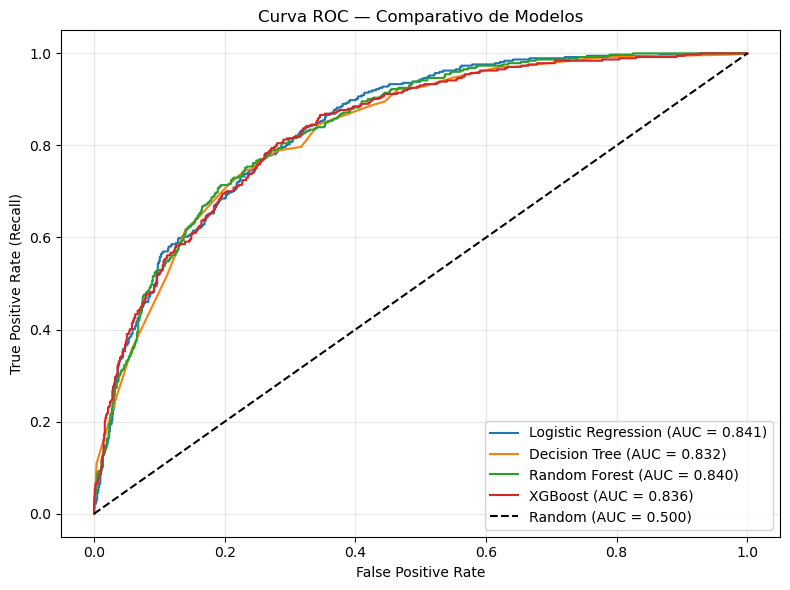

In [33]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

pipelines = {
    "Logistic Regression": lr_model,
    "Decision Tree":       dt_model,
    "Random Forest":       rf_model,
    "XGBoost":             xgb_model,
}

fig, ax = plt.subplots(figsize=(8, 6))

for nome, pipeline in pipelines.items():
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{nome} (AUC = {roc_auc:.3f})")


ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)')


ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("Curva ROC — Comparativo de Modelos")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Observando o comportamento da curva ROC, temos que o modelo de regressão logistica se sai melhor para identificar Positivos reais, comparado aos falsos positivos. 